### Lab 7 ###
*Christopher Cook, Davis Lynn, Anekah Kelley, Bonita Davis*

__Busines Summary__

For Lab 7, we are using the ChatGPT Sentiment Analysis dataset. This dataset that consists of tweets that mention the AI platform ChatGPT. Each tweet is labeled as having a good, neutral, or bad sentiment. The tweets in the dataset were collected over the span of one month and then sentiments were labeled through Natural Language Processing (NLP) techniques. The dataset is available for free on Kaggle through the link below.

Data Source: https://www.kaggle.com/datasets/charunisa/chatgpt-sentiment-analysis

The prediction task we have selected is to classify each tweet by its sentiment using a sequential neural network architecture. We are performing a binary classification as we remove the neutral label, leaving the dataset with tweets of good or bad sentiment. The selected dataset provides a medium-sized text dataset, which is ideal for this prediction task.

The primary business case of this task is to provide marketing feedback to ChatGPT's developers so that they can quickly gain feedback on their marketing campaigns, product announcements, and general perception about their product. By categorizing each tweet by sentiment, ChatGPT can efficiently analyze which features users like, feel neutral about, or dislike. This will allow the developers to highlight features that users love and identify areas of improvement. Additionally, developers can analyze trends and track negative spikes in public sentiment so that they can prepare for potential issues when announcing product updates and manage their brand image.

This sentiment analysis model is applicable for companies across any industry as all companies can benefit from public feedback. For example, retail companies can use sentiment analysis with product reviews to determine popular features in products, or universities can use sentiment analysis with student surveys to improve courses and degree programs. Through analyzing sentiment data, companies can make data-driven decisions to improve their products and enhance customer satisfaction.

### Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import re
import itertools
import tensorflow as tf
import nltk
from tqdm import tqdm

from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dropout, Layer, TextVectorization, Dense, GlobalMaxPooling1D, MultiHeadAttention, LayerNormalization # type: ignore
from tensorflow.keras.regularizers import l1_l2 
from nltk.corpus import stopwords
from sklearn.metrics import recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from keras.layers import Embedding # type: ignore

mpl.style.use("seaborn-v0_8-deep")
mpl.rcParams["figure.figsize"] = (20, 5)
mpl.rcParams["figure.dpi"] = 100
plt.rcParams["figure.dpi"] = 100
plt.rcParams["lines.linewidth"] = 2

nltk.download("vader_lexicon")
nltk.download("punkt")
nltk.download("stopwords")

nltk.data.path.append('/users/cdcook/nltk_data/tokenizers/punkt')

2024-12-12 19:12:16.232351: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-12 19:12:16.812966: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-12 19:12:17.260816: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1734052337.496225 2912121 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1734052337.590338 2912121 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-12 19:12:18.079992: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [2]:
# Load dataset
df = pd.read_csv("./file.csv")
df = df.head(50000)
og_shape = df.shape
print(og_shape)

(50000, 3)


In [3]:
df

,Unnamed: 0,tweets,labels
0,0,ChatGPT: Optimizing Language Models for Dialog...,neutral
1,1,"Try talking with ChatGPT, our new AI system wh...",good
2,2,ChatGPT: Optimizing Language Models for Dialog...,neutral
3,3,"THRILLED to share that ChatGPT, our new model ...",good
4,4,"As of 2 minutes ago, @OpenAI released their ne...",bad
...,...,...,...
49995,49995,The ChatGPT hyperbolic hype train is in overdr...,bad
49996,49996,This instance of artificial intelligence has a...,good
49997,49997,Ripple CTO shuts down ChatGPT’s XRP conspiracy...,bad
49998,49998,The Brilliance and Weirdness of ChatGPT https:...,neutral


In [4]:
def cleanText(txt):
      
    #Creates list of possible stopwords from nltk library
    stop = stopwords.words('english')
    
    # Lowercase
    txt = txt.lower()
    
    # Remove stopwords
    txt = ' '.join([word for word in txt.split() if word not in (stop)])
    
    # Remove non-alphabetic characters
    txt = re.sub('[^a-z]',' ',txt)
    return txt  

def cleanNumbers(x):
    digit_map = {
        '0': 'zero',
        '1': 'one',
        '2': 'two',
        '3': 'three',
        '4': 'four',
        '5': 'five',
        '6': 'six',
        '7': 'seven',
        '8': 'eight',
        '9': 'nine'
    }
    
    x = re.sub('[0-9]{7,}', 'millions', x)
    x = re.sub('[0-9]{4,6}', 'thousand', x)
    x = re.sub('[0-9]{3}', 'hundred', x)
    x = re.sub('[0-9]{2}', 'tens', x)
    x = re.sub('[0-9]{1}', 'tens', x)
    x = re.sub(r'\b\d\b', lambda match: digit_map[match.group()], x)

    return x
contraction_dict = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not", "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not", "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",  "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would", "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would", "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam", "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have", "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have", "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is", "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as", "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would", "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have", "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have", "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are", "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",  "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is", "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have", "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have", "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all", "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have","you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have", "you're": "you are", "you've": "you have"}

def _get_contractions(contraction_dict):
    contraction_re = re.compile('(%s)' % '|'.join(contraction_dict.keys()))
    return contraction_dict, contraction_re

contractions, contractions_re = _get_contractions(contraction_dict)

def replaceContractions(text):
    def replace(match):
        return contractions[match.group(0)]
    return contractions_re.sub(replace, text)


size_mini = 1000

def pre_process(df):
    """
    Parameters:
    - df (pd.Dataframe): The DataFrame to be preprocessed

    Returns: 
    - df (pd.DataFrame): The DataFrame after preprocessed

    """
    # Remove the 'Unnamed: 0' column, if it exists, as it's usually an artifact
    df = df.drop(["Unnamed: 0"], axis=1)
    
    # Map 'labels' values from 'bad'/'good' to 1/0, and set 'neutral' to NaN
    df["labels"] = df["labels"].map({"bad": 1, "good": 0, "neutral": None})
    
    # Drop rows with NaN values in 'labels'
    df = df.dropna(subset=["labels"])

    print("We have kept", (df.shape[0]/og_shape[0])*100, "% of the data")

    # Cleaning the text, numbers, and replacing contractions
    df['tweets'] = df['tweets'].apply(cleanText)
    df['tweets'] = df["tweets"].apply(cleanNumbers)
    df['tweets'] = df["tweets"].apply(replaceContractions)

    return df

In [5]:
def num_characters(df, col_name):
    """
    Adds a new column to the DataFrame containing the number of characters in each message.

    Parameters:
    - df: DataFrame. The DataFrame to which the new column will be added.
    - col_name: str. The name of the column containing the messages.

    Returns:
    - DataFrame. The original DataFrame with a new column added.
    """

    df["Characters"] = df[col_name].apply(len)
    return df


def num_sentences(df, col_name):
    """
    Adds a new column to the DataFrame containing the number of sentences in each message.

    Parameters:
    - df: DataFrame. The DataFrame to which the new column will be added.
    - col_name: str. The name of the column containing the messages.

    Returns:
    - DataFrame. The original DataFrame with a new column added.
    """
    df["Sentences"] = df[col_name].apply(lambda x: len(nltk.sent_tokenize(x)))
    return df


def num_words(df, col_name):
    """
    Adds a new column to the DataFrame containing the number of words in each message.

    Parameters:
    - df: DataFrame. The DataFrame to which the new column will be added.
    - col_name: str. The name of the column containing the messages.

    Returns:
    - DataFrame. The original DataFrame with a new column added.
    """
    df["Words"] = df[col_name].apply(lambda x: len(nltk.word_tokenize(x)))
    return df

In [6]:
df = pre_process(df)

We have kept 74.652 % of the data


In [7]:
df = num_characters(df, "tweets")
df = num_sentences(df, "tweets")
df = num_words(df, "tweets")
df

,tweets,labels,Characters,Sentences,Words
1,try talking chatgpt new ai system optimized d...,0.0,107,1,19
3,thrilled share chatgpt new model optimized di...,0.0,158,1,24
4,minutes ago openai released new chatgpt ...,1.0,112,1,21
5,launched chatgpt new ai system optimized dial...,0.0,113,1,22
6,minutes ago openai released new chatgpt ...,1.0,144,1,31
...,...,...,...,...,...
49994,can t even use regular gpt chatgpt usage bummer,1.0,49,1,9
49995,chatgpt hyperbolic hype train overdrive one...,1.0,210,1,36
49996,instance artificial intelligence fantastic ans...,0.0,117,1,18
49997,ripple cto shuts chatgpt s xrp conspiracy theo...,1.0,72,1,13


In [8]:
def plot_distribution_features(df, features, col_name):
    """
    Plot distributions of specified features in a DataFrame, comparing positive and negative tweets.

    Parameters:
    - df: DataFrame containing the data.
    - features: List of strings, names of the columns for which to plot the distributions.

    Each feature's distribution is plotted in a separate row, with 'good' tweets in blue and 'bad' tweets in pink.
    """
    # Create a figure with subplots arranged in 3 rows and 1 column
    fig, axes = plt.subplots(
        nrows=len(features), ncols=1, figsize=(15, 6 * len(features))
    )

    for i, feature in enumerate(features):
        # Plot distribution for 'good' tweets
        sns.histplot(
            df[df["labels"] == 0][feature],
            kde=True,
            color="#66b3ff",
            label="Positive",
            ax=axes[i],
        )
        # Plot distribution for 'bad' tweets
        sns.histplot(
            df[df["labels"] == 1][feature],
            kde=True,
            color="#ff9999",
            label="Negative",
            ax=axes[i],
        )
        # Setting the title for each subplot
        axes[i].set_title(f"{feature} Distribution for {col_name} dataset")
        # Setting the labels for each subplot
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Count")
        # Adding legend to each subplot
        axes[i].legend()

    # Adjust layout
    plt.tight_layout()
    plt.show()

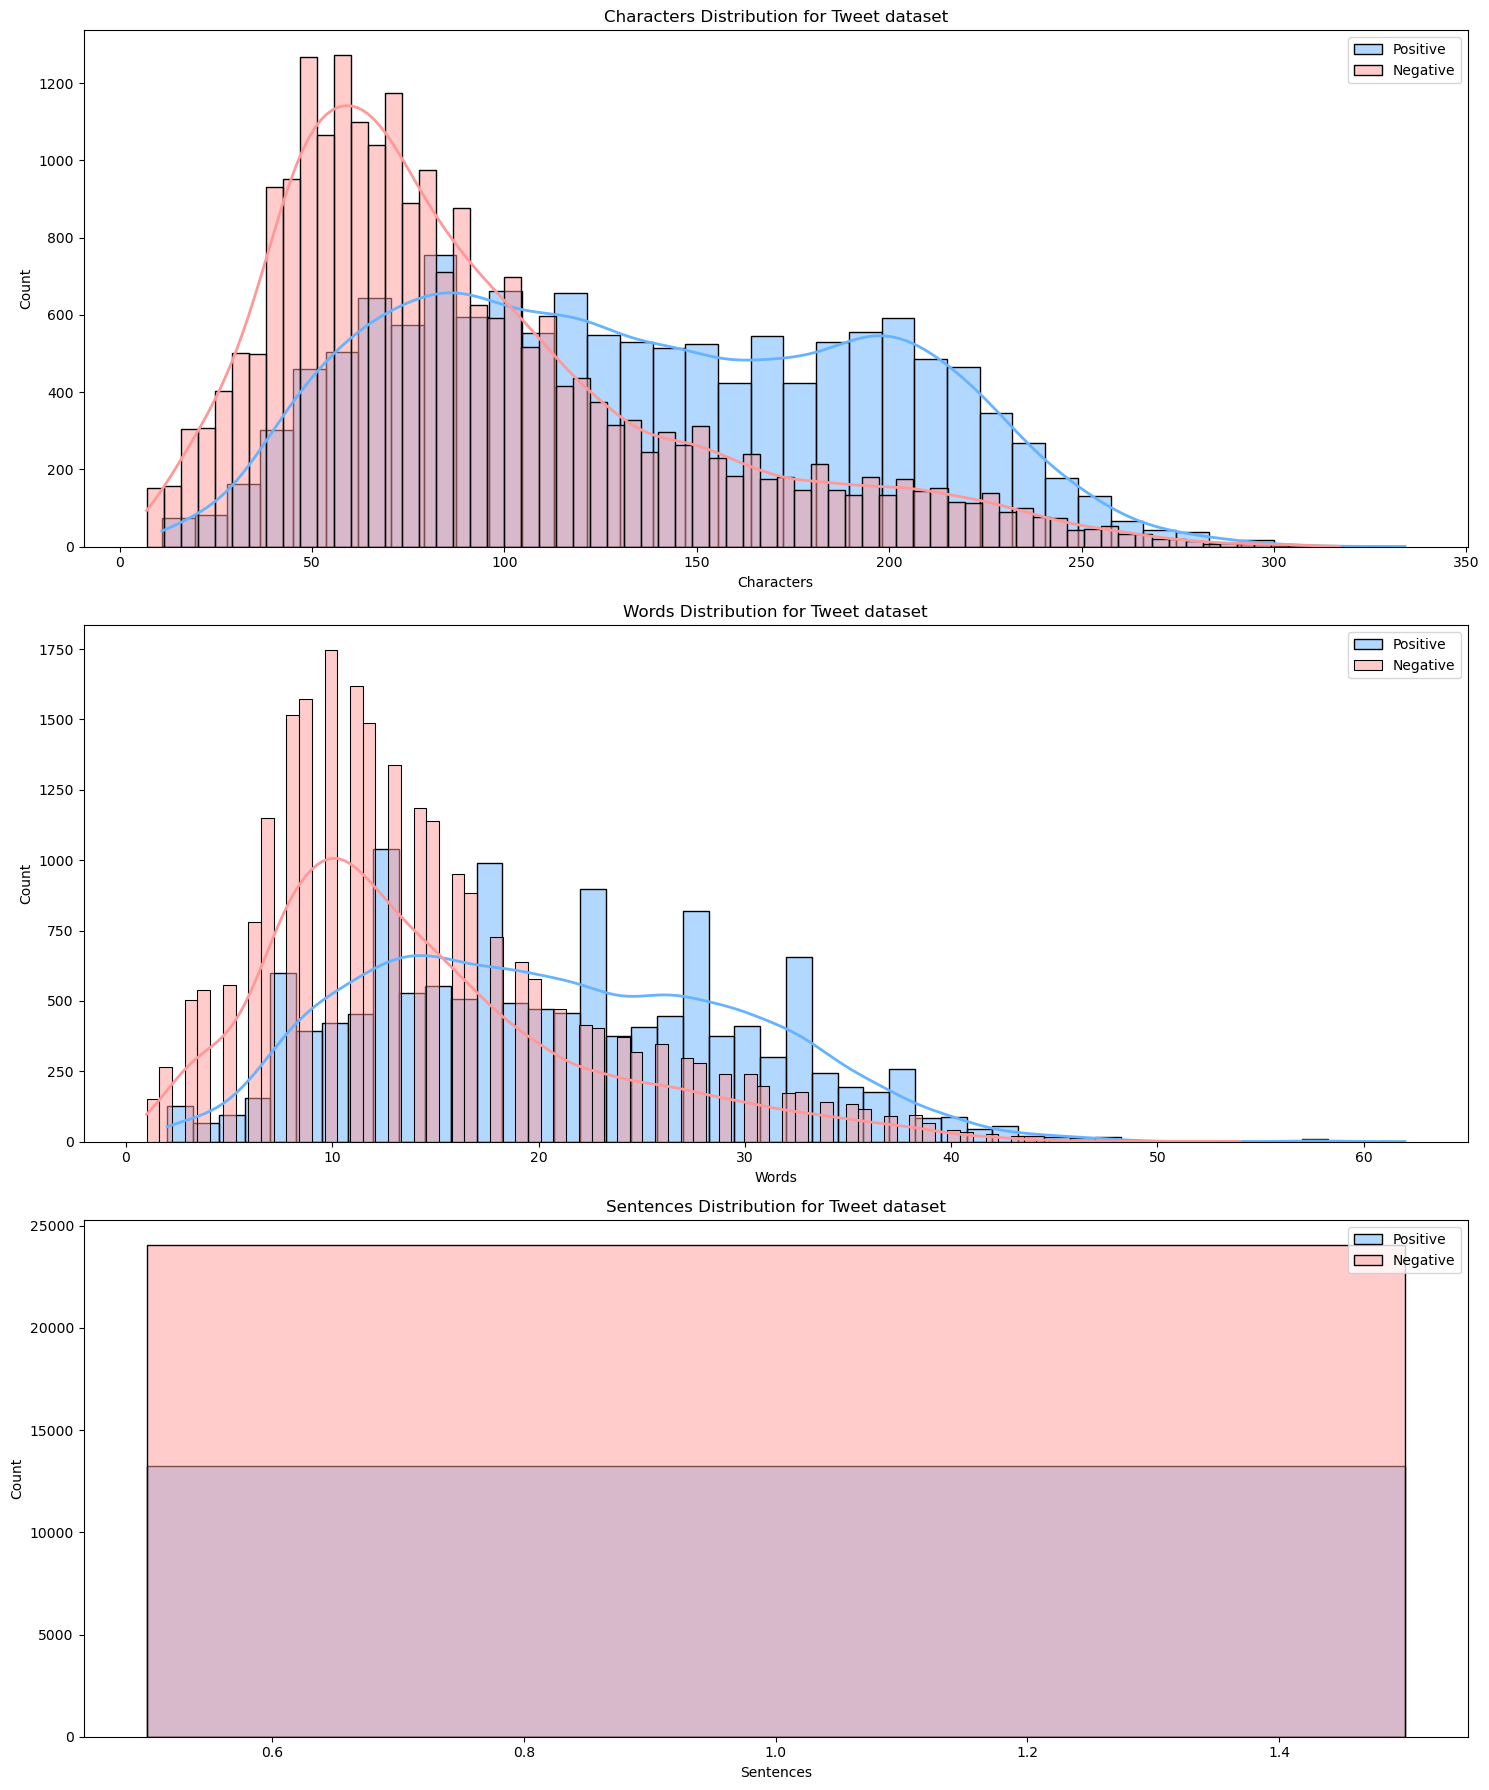

In [9]:
# List of features to plot
features = ["Characters", "Words", "Sentences"]

# Call the function
plot_distribution_features(df, features, "Tweet")

These visualizations show the distribution of characters, words, and sentences in each tweet after preprocessing steps have been applied. According to these plots, negative tweets generally have a lower number of characters and words than positive tweets. Additionally, the sentence distribution plot shows that we have more negative tweets than positive tweets in this dataset.

In [10]:
df['text_length'] = df['tweets'].apply(lambda x: len(x.split()))

# Determine the 95th percentile of these lengths
sequence_length_95 = np.percentile(df['text_length'], 95)

sequence_length = int(np.ceil(sequence_length_95))

print(f"Length covering at least 95% of the Tweets: {sequence_length}")
df = df.drop(columns=["text_length"])
print("The kept sequence is:", sequence_length, "words")

Length covering at least 95% of the Tweets: 34
The kept sequence is: 34 words


In [11]:
max_features = 10000

vectorization = TextVectorization(standardize="lower_and_strip_punctuation", 
                                  max_tokens=max_features, 
                                  output_mode='int', 
                                  output_sequence_length=sequence_length)
vectorization.adapt(df["tweets"])

words_database = vectorization.get_vocabulary()
database_index = {word: index for index, word in enumerate(words_database)}

2024-12-12 19:12:56.999715: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding
import numpy as np
from tqdm import tqdm

# Define max_features and sequence length
max_features = 20000
sequence_length = 100

# Tokenizer to generate word index
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(df['tweets'])
database_index = tokenizer.word_index

# Load GloVe embeddings
def load_glove_index():
    EMBEDDING_FILE = 'glove.twitter.27B.200d.txt'
    def get_coefs(word, *arr): return word, np.asarray(arr, dtype='float32')
    embeddings_index = dict(get_coefs(*o.split(" ")) for o in open(EMBEDDING_FILE, 'r', encoding='utf-8'))
    return embeddings_index

glove_embedding_index_twitter = load_glove_index()

# Create embedding matrix
def create_glove(word_index, embeddings_index):
    all_embs = list(embeddings_index.values())
    embed_size = all_embs[0].shape[0]
    nb_words = min(max_features, len(word_index))
    embedding_matrix = np.random.normal(0, 1, (nb_words, embed_size))

    count_found = nb_words
    for word, i in tqdm(word_index.items()):
        if i >= max_features: continue
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None: 
            embedding_matrix[i] = embedding_vector
        else:
            if word.islower():
                embedding_vector = embeddings_index.get(word.capitalize())
                if embedding_vector is not None: 
                    embedding_matrix[i] = embedding_vector
                else:
                    count_found -= 1
            else:
                count_found -= 1
    print("We found", count_found, "words")
    return embedding_matrix

adapted_glove_twitter = create_glove(database_index, glove_embedding_index_twitter)

# Define embedding layer
embedding_dim = 200
embedding_layer = Embedding(
    input_dim=max_features, 
    output_dim=embedding_dim, 
    weights=[adapted_glove_twitter], 
    input_length=sequence_length, 
    trainable=False
)

100%|██████████| 63531/63531 [00:00<00:00, 1716680.69it/s]

We found 9116 words



/lustre/work/client/users/cdcook/.conda/envs/cobaya_2024/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


__Describe the final dataset that is used for classification/regression (include a description of any newly formed variables you created). Discuss methods of tokenization in your dataset as well as any decisions to force a specific length of sequence.__

The final dataset used for our classification task has undergone several preprocessing and tokenization steps to prepare it for machine learning. Our first preprocessing steps are removing the column "Unnamed: 0" and mapping labels to binary values ("bad": 1, "good": 0, "neutral": None). We then drop rows with NaN labels, which removes all rows with the neutral label. We also use the nltk library to lowercase words and remove stop words. Additionally, we convert numbers into words and expand contractions (eg. ain't -> is not).

To tokenize the tweets in the dataset, we are using the Tokenizer and TextVectorization classes from Keras. We use the Tokenizer class to generate a word index that maps each unique word to a unique integer ID. The TextVectorization class then allows us to split each tweet into individual tokens (words), while also removing punctuation.

To determine the length of sequence, we found the number of tokens in each tweet and found that 95% of the tweets in the dataset have less than 35 tokens, so we adapted the dataset for each tweet to have 34 tokens by either adding tokens to bring the tweets up to 34 tokens or truncating tokens down to 34. Bringing the values to the same number of tokens allows the values to be passed into our model consistently, ensuring good performance.

__Choose and explain what metric(s) you will use to evaluate your algorithm’s performance.__

We have decided to use recall, F1, specificity, and AUC-ROC to evaluate the performance of our sentiment classification model. These metrics provide a comprehensive assessment of the model's ability to classify tweets as having "good" or "bad" sentiments.

Recall measures the proportion of true positives out of all positive instances. In this case, true positives are the number of "bad" sentiment tweets that were correctly classified as "bad", and a false negatives are the number of "bad" sentiment tweets that were incorrectly classified as "good". For our prediction task, we want to identify as many negative sentiment tweets as possible so that companies can effectively address negative feedback and improve their product.

F1 score calculates a harmonic mean of precision and recall, which is helpful as it will ensure that we minimize both false negatives and false positives. Furthermore, our dataset is imbalanced, with only about a third of the dataset being comprised of "good" tweets, so F1 score will provide a balanced evaluation of model performance for both classes and ensure that the model effectively identifies "bad" sentiment while not misclassifying "good" sentiment too often.

Specificity measures the proportion of true negatives out of all negative instances. In this case, true negatives are the number of "good" sentiment tweets correctly classified as "good", and false positives are the number of "good" sentiment tweets incorrectly classified as "bad". Measuring specificity is important because we want to ensure that good feedback is not misclassified as bad. This misclassification can cause the company to waste time and resources addressing features that are well-received by customers.

AUC-ROC provides a more nuanced performance evaluation, particularly in distinguishing between classes at various decision thresholds. While accuracy measures the overall correctness, AUC-ROC focuses on the model's ability to discriminate between classes, making it an ideal metric for understanding how well the model performs across different thresholds. This metric will give us insight into how the model performs across the classes despite the class imbalance in our dataset.

These four metrics provide a well-rounded evaluation of our model's performance. Recall ensures we correctly classify negative feedback, and F1 score balances the model's performance between the two sentiment classes. Specificity ensures we do not misclassify positive feedback, and AUC-ROC provides a robust assessment of the model's ability to distinguish between the two classes. Together, these performance metrics will allow us to effectively evaluate our model's performance and ensure we meet the requirements of our business case.



__Choose the method you will use for dividing your data into training and testing__

We chose to divide our data using stratified 10-fold cross-validation because this method is best suited for our prediction task. Stratified 10-fold cross-validation ensures that each fold in the cross-validation process maintains the same proportion of samples from each class as in the full dataset. Since we have 18 character classes, this method ensures that each training and test subset is representative of the overall distribution of characters. This is important as we want to ensure the model is trained and tested on balanced data to avoid any potential biases that could happen if there were classes that are underrepresented in certain folds.

Furthermore, by using stratified 10-fold cross-validation, we ensure that every data point is used both for training and testing across different folds, allowing the model to be evaluated on multiple splits of the data. This reduces the variance of the performance estimate, providing a more reliable understanding of how the model will perform on unseen data. With 10 folds, each model is tested on a different partition, and we can compute an average accuracy (and AUC score) across all folds to get a more stable performance metric.

Stratified 10-fold cross-validation is a realistic mirroring of how an algorithm would be evaluated in practice, especially when the goal is to ensure the model generalizes well to unseen data. In real-world applications, models are often deployed to classify new, unseen data. By using this method, we mimic this process by repeatedly testing the model on data that it had not seen during training. This iterative testing approach helps to evaluate how well the model generalizes across different subsets of the dataset and provides a realistic simulation of how the model would be deployed.

### Modeling

In this section, we will investigate four different sequential network architectures: GRU, LSTM, Simple RNN, and Transformer. We will use a pre-trained GloVe embedding of 200 dimensions to initialize the embedding layer. Using a pre-trained embedding will help our model learn semantic relationships between words without training from scratch, which will improve generalization.

In [13]:
from tensorflow.keras.layers import TextVectorization

# Parameters for vectorization
max_tokens = 20000  # Maximum number of unique tokens
sequence_length = 100  # Length of sequences to pad or truncate to

# Define the TextVectorization layer
vectorization = TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=sequence_length
)

# Adapt the vectorization layer to your dataset
# Assuming `text_dataset` is a tf.data.Dataset of raw text
vectorization.adapt(df['tweets'])

def gru_model():
    model = Sequential()
    model.add(tf.keras.Input(shape=(1,), dtype=tf.string))  # Input layer for raw strings
    model.add(vectorization)
    model.add(embedding_layer)
    model.add(GRU(128, return_sequences=True))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu', kernel_regularizer=l1_l2(0.01)))
    model.add(Dense(1, activation='sigmoid'))

    return model

def lstm_model():
    model = Sequential()
    model.add(tf.keras.Input(shape=(1,), dtype=tf.string))  # Input layer for raw strings
    model.add(vectorization)
    model.add(embedding_layer)
    model.add(LSTM(128, return_sequences=True))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu', kernel_regularizer=l1_l2(0.01)))
    model.add(Dense(1, activation='sigmoid'))

    return model

def rnn_model():
    model = Sequential()
    model.add(tf.keras.Input(shape=(1,), dtype=tf.string))  # Input layer for raw strings
    model.add(vectorization)
    model.add(embedding_layer)
    model.add(SimpleRNN(128, return_sequences=True))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu', kernel_regularizer=l1_l2(0.01)))
    model.add(Dense(1, activation='sigmoid'))

    return model

class TransformerBlock(Layer): # inherit from Keras Layer
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.2):
        super().__init__()
        # setup the model heads and feedforward network
        self.att = MultiHeadAttention(num_heads=num_heads, 
                                      key_dim=embed_dim)
        
        # make a two layer network that processes the attention
        self.ffn = Sequential()
        self.ffn.add( Dense(ff_dim, activation='relu') )
        self.ffn.add( Dense(embed_dim) )
        
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=True):
        # apply the layers as needed (similar to PyTorch)
        
        # get the attention output from multi heads
        # Using same inpout here is self-attention
        # call inputs are (query, value, key) 
        # if only two inputs given, value and key are assumed the same
        attn_output = self.att(inputs, inputs)
        
        # create residual output, with attention
        out1 = self.layernorm1(inputs + attn_output)
        
        # apply dropout if training
        out1 = self.dropout1(out1, training=training)
        
        # place through feed forward after layer norm
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        
        # apply dropout if training
        out2 = self.dropout2(out2, training=training)
        #return the residual from Dense layer
        return out2
    
    
class TokenAndPositionEmbedding(Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        # create two embeddings 
        # one for processing the tokens (words)
        self.token_emb = Embedding(input_dim=vocab_size, 
                                   output_dim=embed_dim)
        # another embedding for processing the position
        self.pos_emb = Embedding(input_dim=maxlen, 
                                 output_dim=embed_dim)

    def call(self, x):
        # create a static position measure (input)
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        # positions now goes from 0 to 500 (for IMdB) by 1
        positions = self.pos_emb(positions)# embed these positions
        x = self.token_emb(x) # embed the tokens
        return x + positions # add embeddngs to get final embedding

def transformer_model():
    embed_dim = embedding_dim  # Assuming you are using GloVe embeddings with dimension 200
    num_heads = 1
    ff_dim = 32

    inputs = tf.keras.Input(shape=(sequence_length,), dtype=tf.int32)  # Use dtype=tf.string for token sequences
    x = inputs
    x = TokenAndPositionEmbedding(sequence_length, max_features, embed_dim)(x)
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(20, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

In [14]:
def train_and_evaluate_model(model, train_df, test_df, epochs=20):

    model.summary()
    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model and store the training history
    history = model.fit(train_df['tweets'], train_df['labels'], epochs=epochs, validation_data=(test_df['tweets'], test_df['labels']))

    # Return the training history and the trained model
    return history, model

# Function to plot the training and validation accuracy and loss
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.suptitle(title)

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

In [15]:
model_variations = [
    (rnn_model),
    (lstm_model),
    (gru_model),
    # (transformer_model) - Added below b/c different architecture
]
epochs = 20

histories = []
models = []

train_df, test_df = train_test_split(df, test_size=0.2, random_state=10)

for model_func in model_variations:
    _model = model_func()
    history, model = train_and_evaluate_model(model=_model, train_df=train_df, test_df=test_df, epochs=epochs)
    histories.append(history)
    models.append(model)

# Add the transformer model to the list of models
train_sequences = vectorization(train_df['tweets'])
test_sequences = vectorization(test_df['tweets'])

trans_model = transformer_model()

trans_model.summary()
trans_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
trans_history = trans_model.fit(train_sequences, train_df['labels'], epochs=epochs, validation_data=(test_sequences, test_df['labels']))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 200)       │     4,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100, 128)       │        42,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,433 (15.45 MB)

 Trainable params: 50,433 (197.00 KB)

 Non-trainable params: 4,000,000 (15.26 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 100, 200)       │     4,020,000 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 100, 200)       │       174,632 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 200)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 20)             │         4,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,198,673 (16.02 MB)

 Trainable params: 4,198,673 (16.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 46s 47ms/step - accuracy: 0.7660 - loss: 0.4645 - val_accuracy: 0.9445 - val_loss: 0.1610
Epoch 2/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9605 - loss: 0.1262 - val_accuracy: 0.9466 - val_loss: 0.1914
Epoch 3/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9816 - loss: 0.0623 - val_accuracy: 0.9478 - val_loss: 0.1674
Epoch 4/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 46s 49ms/step - accuracy: 0.9871 - loss: 0.0422 - val_accuracy: 0.9425 - val_loss: 0.1818
Epoch 5/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9888 - loss: 0.0383 - val_accuracy: 0.9423 - val_loss: 0.2419
Epoch 6/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9934 - loss: 0.0250 - val_accuracy: 0.9429 - val_loss: 0.2336
Epoch 7/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9952 - loss: 0.0181 - val_accuracy: 0.9348 - val_loss: 0.2591
Epoch 8/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9911 - loss: 0.0288 - 

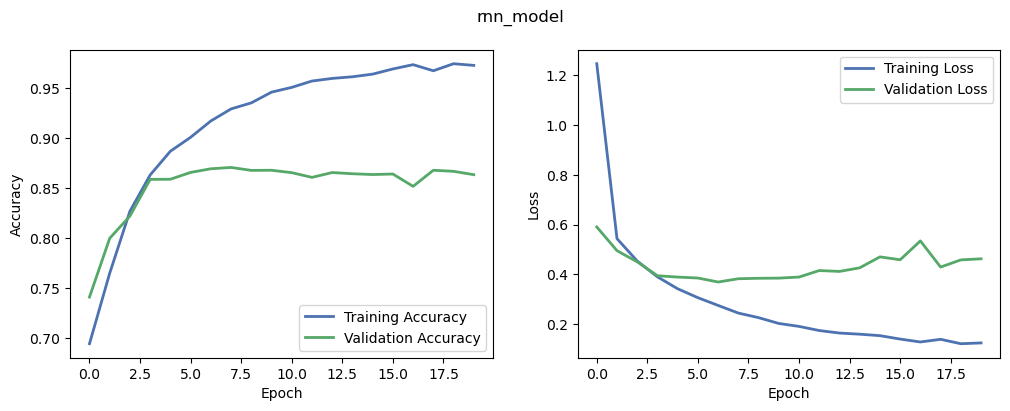

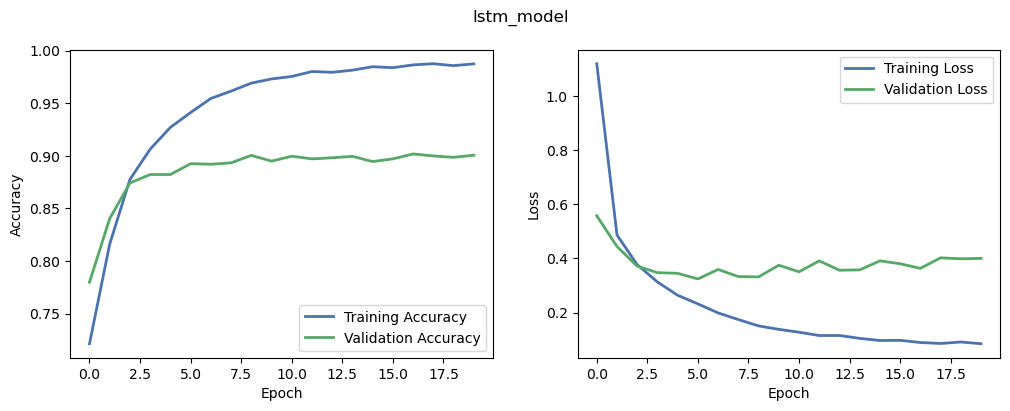

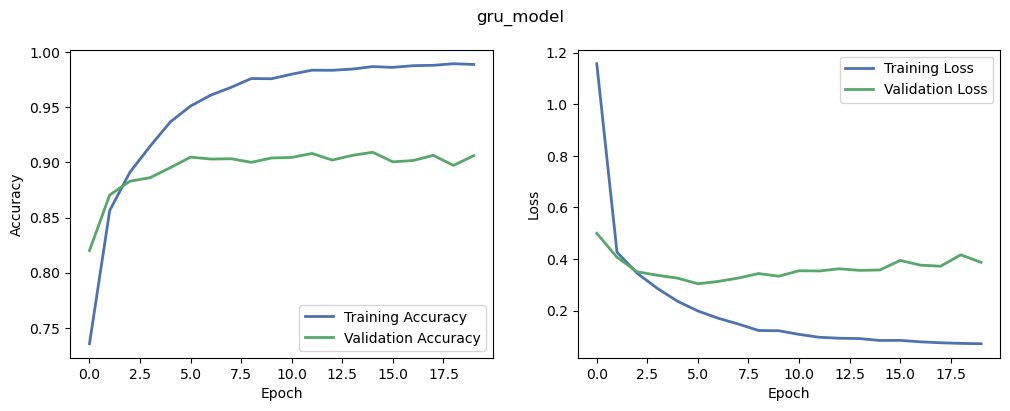

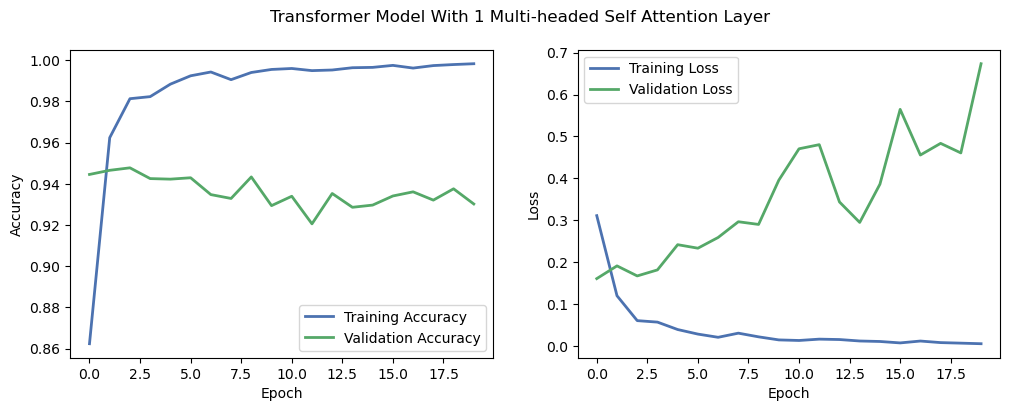

In [16]:
# Visualize the performance of all model variations
for i, history in enumerate(histories):
    model_func = model_variations[i]
    title = f"{model_func.__name__}"
    plot_history(history, title=f"{title}")

# Plot Transformer Model as well
plot_history(trans_history, title=f"Transformer Model With 1 Multi-headed Self Attention Layer")

The training and validation performance graphs illustrate the convergence of each of our models. The simple RNN, ISTM, and GRU models demonstrate convergence, evidenced by the steady decrease and plateau of their training loss and the relative stability of their validation loss. Accuracy also becomes relatively stable.

In contrast, the Transformer model does not fully converge, as its validation loss is increasing in later epochs, and its validation accuracy is fluctuating more than the other models. These patterns suggest that the Transformer model may require further tuning, which we will do by adding a second Multi-headed self attention layer in the next section.

In [17]:
def transformer_model2():
    embed_dim = embedding_dim  # Assuming you are using GloVe embeddings with dimension 200
    num_heads = 2
    ff_dim = 32

    inputs = tf.keras.Input(shape=(sequence_length,), dtype=tf.int32)  # Use dtype=tf.string for token sequences
    x = inputs
    x = TokenAndPositionEmbedding(sequence_length, max_features, embed_dim)(x)
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(20, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_1  │ (None, 100, 200)       │     4,020,000 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 100, 200)       │       335,232 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 200)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 20)             │         4,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,359,273 (16.63 MB)

 Trainable params: 4,359,273 (16.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 60s 62ms/step - accuracy: 0.7874 - loss: 0.4393 - val_accuracy: 0.9440 - val_loss: 0.1592
Epoch 2/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.9612 - loss: 0.1183 - val_accuracy: 0.9396 - val_loss: 0.1752
Epoch 3/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.9828 - loss: 0.0614 - val_accuracy: 0.9348 - val_loss: 0.2215
Epoch 4/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.9842 - loss: 0.0534 - val_accuracy: 0.9427 - val_loss: 0.2109
Epoch 5/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.9886 - loss: 0.0431 - val_accuracy: 0.9345 - val_loss: 0.2667
Epoch 6/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.9915 - loss: 0.0274 - val_accuracy: 0.9345 - val_loss: 0.3073
Epoch 7/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.9936 - loss: 0.0213 - val_accuracy: 0.9346 - val_loss: 0.2812
Epoch 8/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.9936 - loss: 0.0200 - 

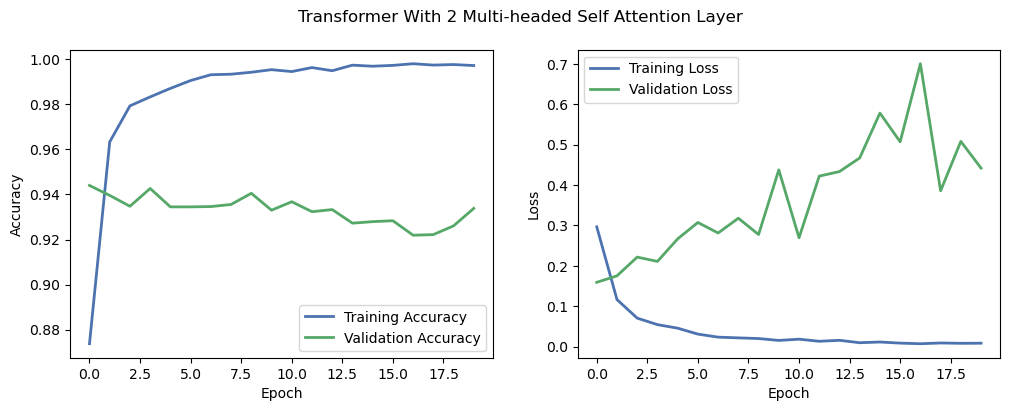

In [18]:
trans_model2 = transformer_model2()

trans_model2.summary()
trans_model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
trans_history2 = trans_model2.fit(train_sequences, train_df['labels'], epochs=epochs, validation_data=(test_sequences, test_df['labels']))

plot_history(trans_history2, title=f"Transformer With 2 Multi-headed Self Attention Layer")

This graph shows the convergence of the Transformer model with two Multi-headed self attention layers. In comparison to the first Transformer model, this model shows some improvements in performance. The validation loss still increases in later epochs, showing the model does not fully converge in terms of validation performance. However, the validation accuracy of this model is more stable, showing that this Transformer model converges better than the previous Transformer model.

[2]Use the method of train/test splitting and evaluation criteria that you argued for at the beginning of the lab. Visualize the results of all the models you trained.  Use proper statistical comparison techniques to determine which method(s) is (are) superior.  


In [19]:
# Calculate evaluation metrics for all model variations
evaluation_results = []


X_test = test_df['tweets']
y_test = test_df['labels']


for model in models:
    y_pred = model.predict(X_test)  # Assuming X_test and y_test are the test data
    y_pred_binary = (y_pred > 0.5).astype(int)  # Convert probabilities to binary predictions

    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    specificity = tn / (tn + fp)
    auc_roc = roc_auc_score(y_test, y_pred)

    evaluation_results.append((recall, f1, specificity, auc_roc))

234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step
234/234 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step


In [20]:
for result in evaluation_results:
    print(result)


def calculate_metrics_for_transformer_model(trans_model):
    X_test = test_sequences
    y_pred = trans_model.predict(X_test) 
    y_pred_binary = (y_pred > 0.5).astype(int)

    recall = recall_score(y_test, y_pred_binary)
    f1 = f1_score(y_test, y_pred_binary)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
    specificity = tn / (tn + fp)
    auc_roc = roc_auc_score(y_test, y_pred)

    return [recall, f1, specificity, auc_roc]

evaluation_results_transformer_1 = calculate_metrics_for_transformer_model(trans_model)
evaluation_results_transformer_2 = calculate_metrics_for_transformer_model(trans_model2)

(0.8868278449353898, 0.8929695697796433, 0.8212143928035982, 0.926000721502525)
(0.9285118799499792, 0.9231247409863241, 0.8504497751124438, 0.9512346395580867)
(0.9237182159233014, 0.9267119707266074, 0.8744377811094453, 0.9510721921240297)
234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step
234/234 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step


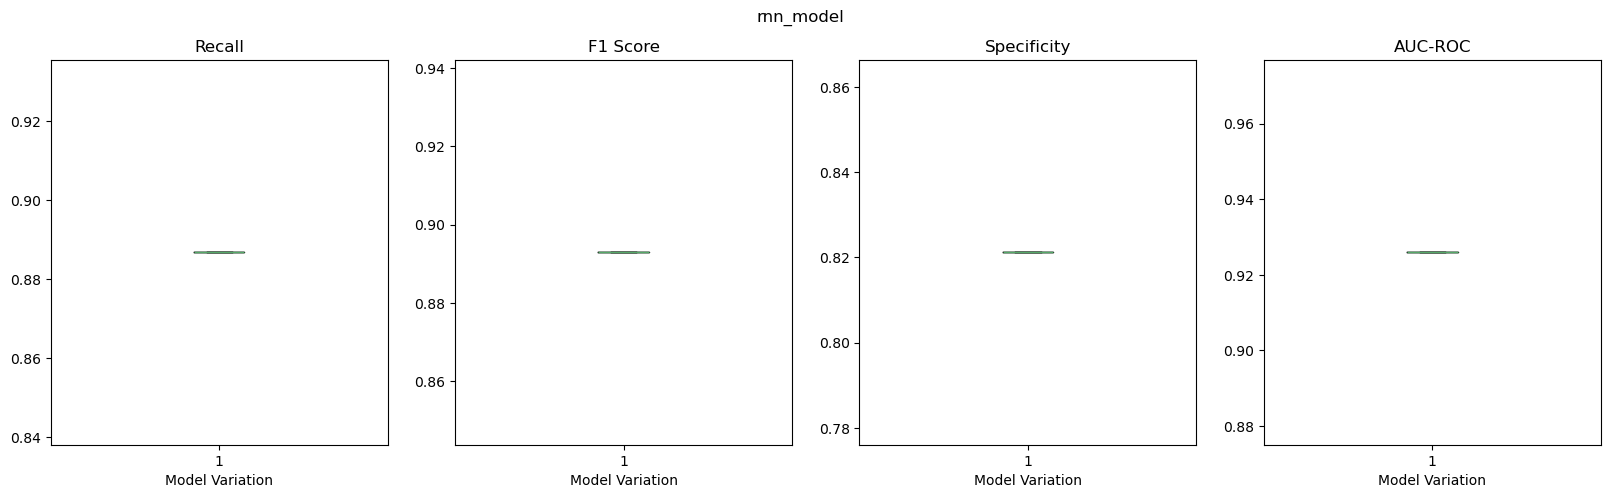

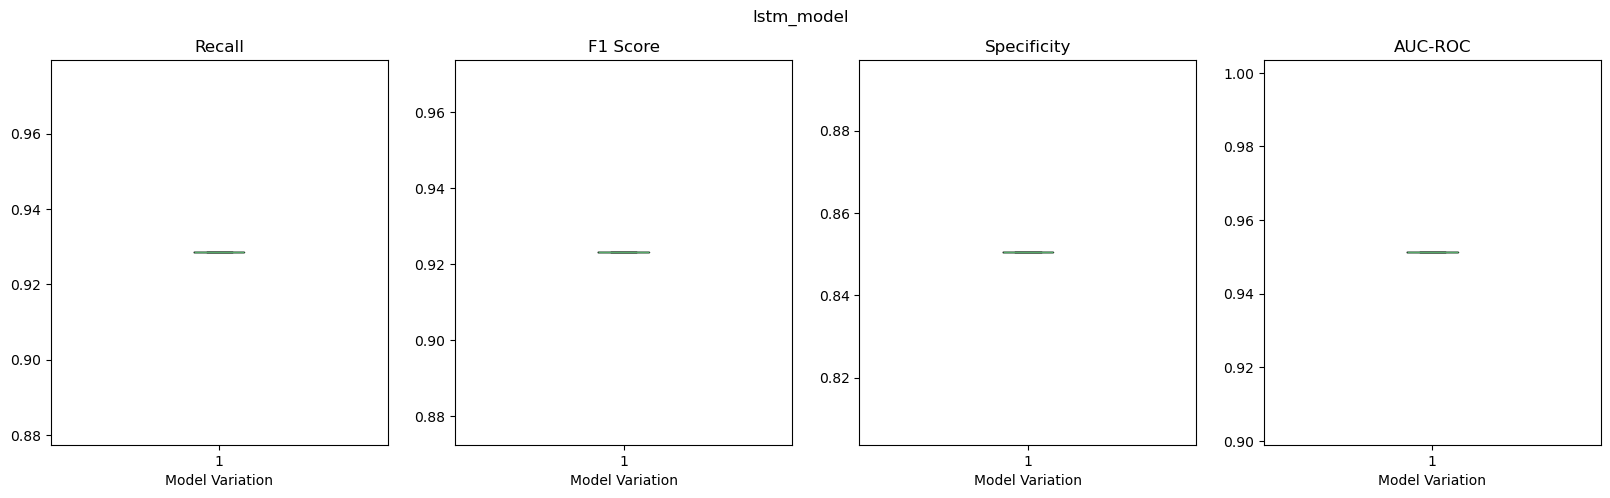

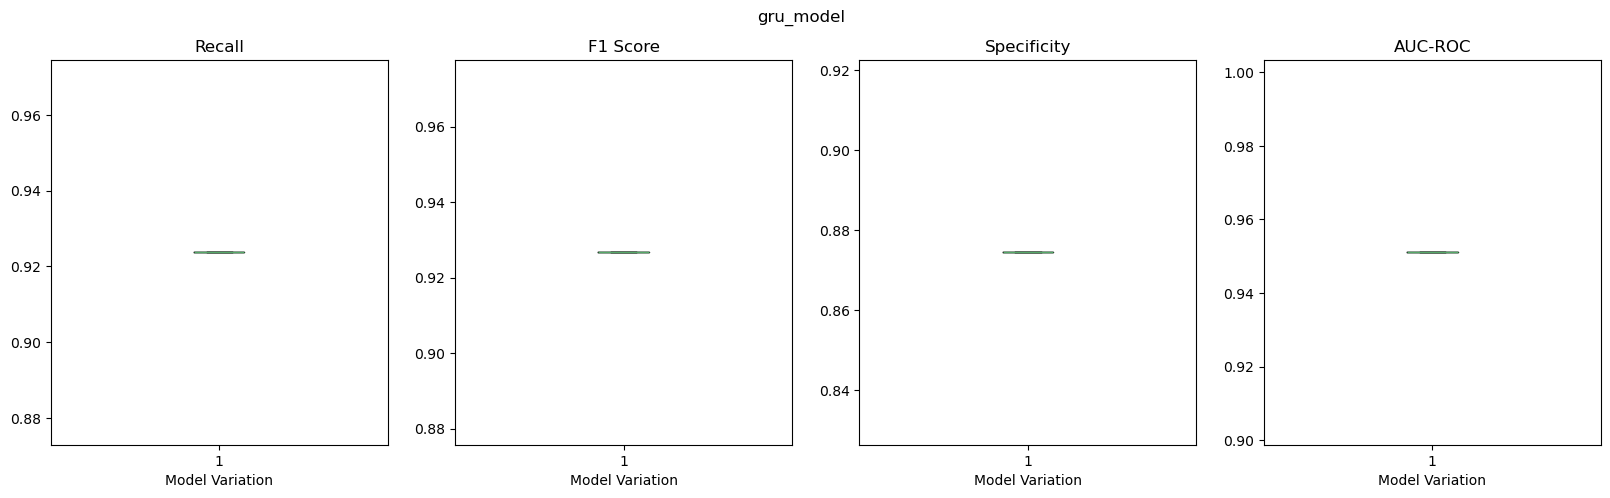

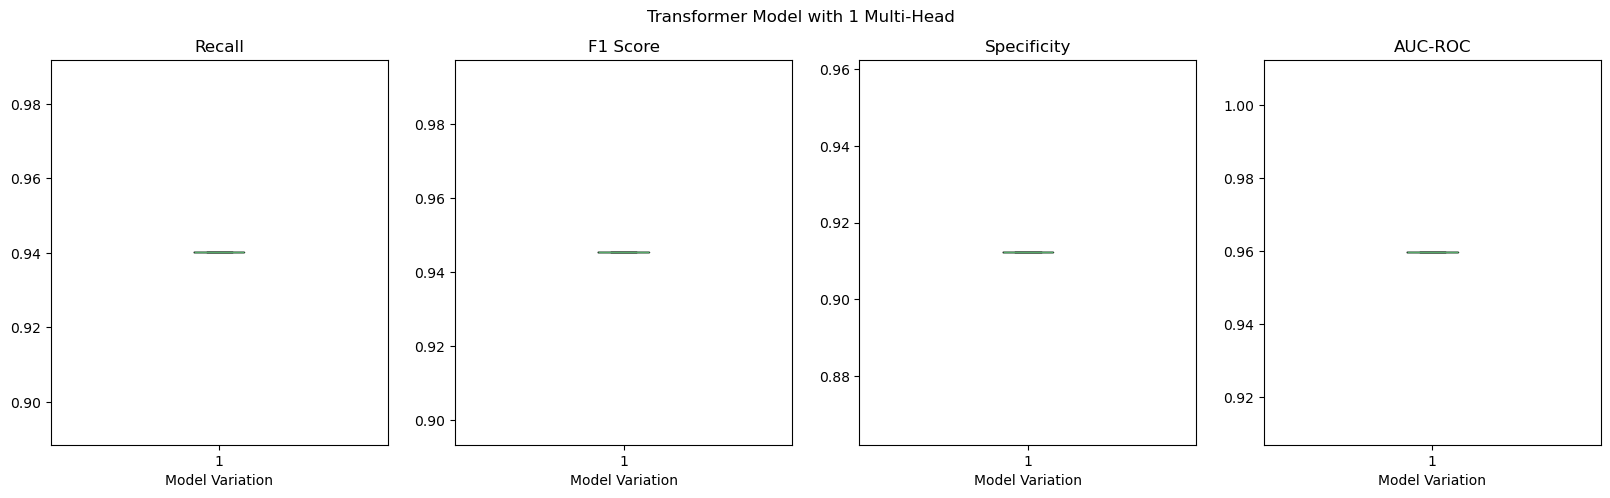

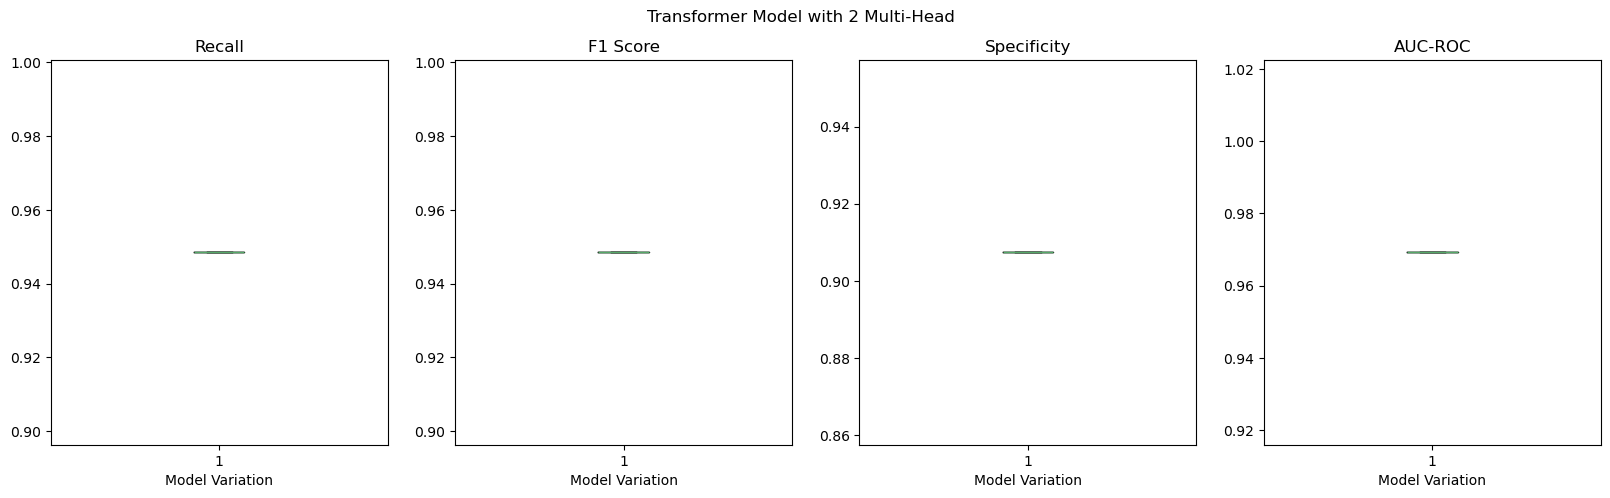

In [21]:
# Visualize the evaluation metrics
metric_names = ['Recall', 'F1 Score', 'Specificity', 'AUC-ROC']

for idx, (model_func) in enumerate(model_variations):
    title = f"{model_func.__name__}"
    plt.suptitle(title)
    for j, metric_name in enumerate(metric_names):
        metric_value = evaluation_results[idx][j]
        plt.subplot(1, len(metric_names), j+1)
        plt.boxplot([metric_value])
        plt.title(metric_name)
        plt.xlabel('Model Variation')

    plt.show()

# Transformer 1
plt.suptitle(f"Transformer Model with 1 Multi-Head")
for j, metric_name in enumerate(metric_names):
    metric_value = evaluation_results_transformer_1[j]
    plt.subplot(1, len(metric_names), j+1)
    plt.boxplot([metric_value])
    plt.title(metric_name)
    plt.xlabel('Model Variation')

plt.show()

# Transformer 2
plt.suptitle(f"Transformer Model with 2 Multi-Head")
for j, metric_name in enumerate(metric_names):
    metric_value = evaluation_results_transformer_2[j]
    plt.subplot(1, len(metric_names), j+1)
    plt.boxplot([metric_value])
    plt.title(metric_name)
    plt.xlabel('Model Variation')
plt.show()

In [22]:
import pandas as pd
from tabulate import tabulate

# Define evaluation results for each model
evaluation_results_dict = {
    "Model Variation": [model_func.__name__ for model_func in model_variations] + 
                       ["Transformer Model (1 Multi-Head)", "Transformer Model (2 Multi-Head)"],
    "Recall": [evaluation_results[idx][0] for idx in range(len(model_variations))] +
              [evaluation_results_transformer_1[0], evaluation_results_transformer_2[0]],
    "F1 Score": [evaluation_results[idx][1] for idx in range(len(model_variations))] +
                [evaluation_results_transformer_1[1], evaluation_results_transformer_2[1]],
    "Specificity": [evaluation_results[idx][2] for idx in range(len(model_variations))] +
                   [evaluation_results_transformer_1[2], evaluation_results_transformer_2[2]],
    "AUC-ROC": [evaluation_results[idx][3] for idx in range(len(model_variations))] +
               [evaluation_results_transformer_1[3], evaluation_results_transformer_2[3]],
}

# Convert to DataFrame
evaluation_df = pd.DataFrame(evaluation_results_dict)

# Print the table in a readable format
print(tabulate(evaluation_df, headers='keys', tablefmt='pretty'))

+---+----------------------------------+--------------------+--------------------+--------------------+--------------------+
|   |         Model Variation          |       Recall       |      F1 Score      |    Specificity     |      AUC-ROC       |
+---+----------------------------------+--------------------+--------------------+--------------------+--------------------+
| 0 |            rnn_model             | 0.8868278449353898 | 0.8929695697796433 | 0.8212143928035982 | 0.926000721502525  |
| 1 |            lstm_model            | 0.9285118799499792 | 0.9231247409863241 | 0.8504497751124438 | 0.9512346395580867 |
| 2 |            gru_model             | 0.9237182159233014 | 0.9267119707266074 | 0.8744377811094453 | 0.9510721921240297 |
| 3 | Transformer Model (1 Multi-Head) | 0.9401834097540642 | 0.9454050089070523 | 0.9122938530734632 | 0.9597094429025587 |
| 4 | Transformer Model (2 Multi-Head) | 0.9485202167569821 | 0.9485202167569821 | 0.9074212893553223 | 0.9692597818431343 |


At the beginning of the lab, we argued for using an 80/20 train-test split and for using recall, F1 score, specificity, and AUC-ROC as our performance evaluation criteria.

Above are the performance results of our five models. Transformer models consistently outperform all other models across all evaluation metrics. The Transformer model with 2 Multi-Heads has the best overall performance, achieving the highest Recall (0.9485), F1 Score (0.9485), and AUC-ROC (0.9693) and the second highest Specificity (0.9074). The Transformer model with 1 Multi-Head is not too far behind the 2 multi-head model in performance, achieving the highest Specificity (0.9123), and the second highest Recall (0.9402), F1 Score (0.9454), and AUC-ROC (0.9597).

The GRU and LSTM models perform similarly but are still behind the Transformer models in overall performance. The GRU model achieves a Recall of 0.9237, F1 Score of 0.9267, Specificity of 0.8744, and AUC-ROC of 0.9511, while the LSTM model achieves a Recall of 0.9285, F1 Score of 0.9231, Specificity of 0.8504, and AUC-ROC of 0.9512.

The simple RNN model ranks the lowest across all evaluation metrics, with a Recall of 0.8868, F1 Score of 0.8930, Specificity of 0.8212, and AUC-ROC of 0.9260. This suggests that the simple RNN is the least effective model for this prediction task.

In [41]:
def plot_confusion_matrix(cm, classes, title="Confusion matrix"):
    plt.figure(figsize=(5, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
        )

    plt.tight_layout()
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.grid(False)
    plt.show()

234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


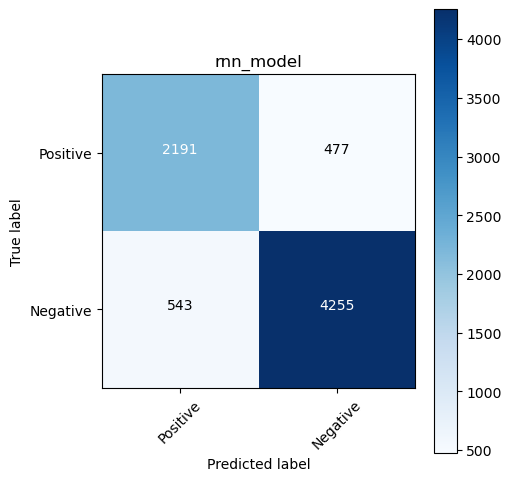

234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step


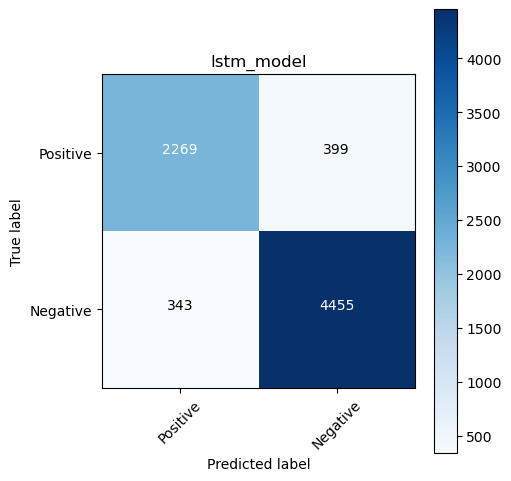

234/234 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step


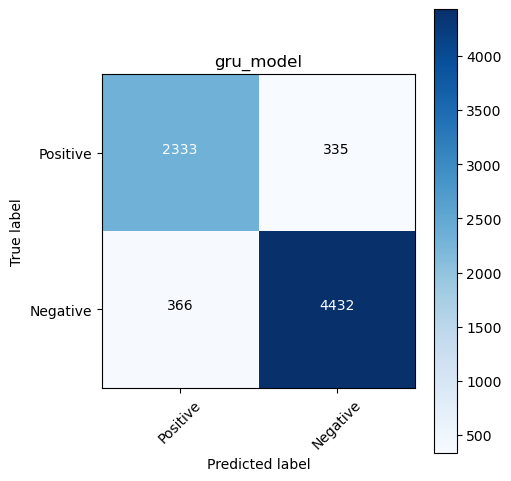

234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step


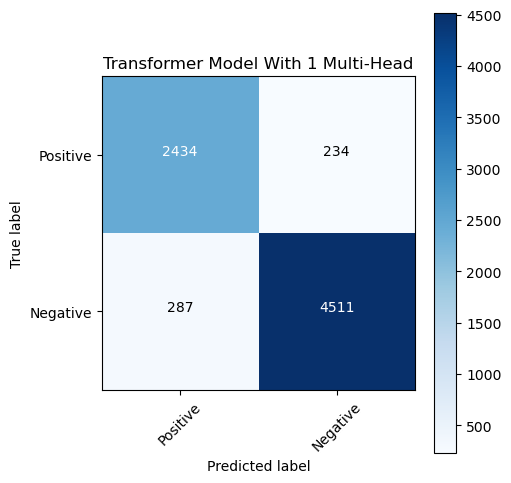

234/234 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step


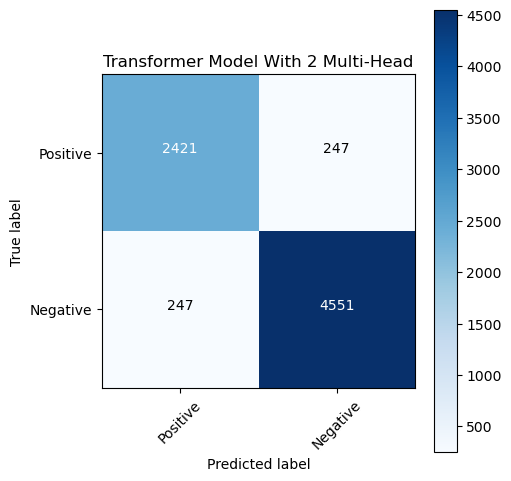

In [23]:
classes = ["Positive", "Negative"]

for idx, (model) in enumerate(models):
    model_func = model_variations[idx]
    title = f"{model_func.__name__}"

    # Calculate confusion matrix
    pred = model.predict(test_df['tweets'])
    y_pred_binary = (pred > 0.5).astype(int)  # Convert probabilities to binary predictions
    cm = confusion_matrix(test_df['labels'], y_pred_binary)
    plot_confusion_matrix(cm, classes, title)

# Transformer Model with 1 Multi-Head
predictions1 = trans_model.predict(test_sequences)
predicted_labels1 = (predictions1 > 0.5).astype(int)
trans_conf_matrix = confusion_matrix(test_df['labels'], predicted_labels1)
plot_confusion_matrix(trans_conf_matrix, classes, title="Transformer Model With 1 Multi-Head")

# Transformer Model with 2 Multi-Head
predictions2 = trans_model2.predict(test_sequences)
predicted_labels2 = (predictions2 > 0.5).astype(int)
trans_conf_matrix2 = confusion_matrix(test_df['labels'], predicted_labels2)
plot_confusion_matrix(trans_conf_matrix2, classes, title="Transformer Model With 2 Multi-Head")

The confusion matrices for each model further confirm that the Transformer models outperformed all other models. The Transformer model with 2 multi-heads had the highest number of true negatives (4551) and the lowest number of false positives (247), indicating a strong ability to correctly classify negative cases while minimizing false positives.

The Transformer model with 1 multi-head performed similarly well, with the highest number of true positives (2434) and the lowest number of false negatives (234), suggesting that it effectively identified positive cases while minimizing false negatives.

The GRU and LSTM models again performed similarly, with the GRU model having the third-highest number of true positives (2333), and the LSTM model having the third-highest number of true negatives (4455). This shows that they performed well but are still behind both Transformer models.

The simple RNN model ranked the lowest again across all categories, with 2191 true positives, 477 false negatives, 4255 true negatives, and 543 false positives. This further proves that the simple RNN model was less effective in performing this prediction task compared to the other models.

__Exceptional Work__

[1]Use the pre-trained ConceptNet Numberbatch embedding and compare to pre-trained GloVe. Which method is better for your specific application?

In [37]:
def prepare_embedding_matrix(glove_embeddings, max_features, embedding_dim):
    embedding_matrix = np.zeros((max_features, embedding_dim))
    for word, i in database_index.items():
        if i < max_features:
            embedding_vector = glove_embeddings.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector
    return embedding_matrix

# Load GloVe embeddings
def load_glove_embeddings(file):
    embeddings = {}
    with open(file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings[word] = coefs
    return embeddings

glove_embeddings = load_glove_embeddings('glove.6B.100d.txt')

glove_embedding_matrix = prepare_embedding_matrix(glove_embeddings, max_features, embedding_dim=100)

glvoe_embedding_layer = Embedding(input_dim=max_features, output_dim=100, weights=[glove_embedding_matrix], input_length=sequence_length, trainable=False)

# Define a model using the GloVe embeddings
def model_with_glove_embeddings():
    model = Sequential()
    model.add(tf.keras.Input(shape=(1,), dtype=tf.string))  # Input layer for raw strings
    model.add(vectorization)
    model.add(glvoe_embedding_layer)
    model.add(LSTM(128, return_sequences=True))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu', kernel_regularizer=l1_l2(0.01)))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Load ConceptNet Numberbatch embeddings
def load_numberbatch_embeddings(file):
    embeddings = {}
    with open(file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings[word] = coefs
    return embeddings

numberbatch_embeddings = load_numberbatch_embeddings('numberbatch-en-19.08.txt')

numberbatch_embedding_matrix = prepare_embedding_matrix(numberbatch_embeddings, max_features, embedding_dim=300)

numberbatch_embedding_layer = Embedding(input_dim=max_features, output_dim=300, weights=[numberbatch_embedding_matrix], input_length=sequence_length, trainable=False)

# Define a model using the Numberbatch embeddings
def model_with_numberbatch_embeddings():
    model = Sequential()
    model.add(tf.keras.Input(shape=(1,), dtype=tf.string))  # Input layer for raw strings
    model.add(vectorization)
    model.add(numberbatch_embedding_layer)
    model.add(LSTM(128, return_sequences=True))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu', kernel_regularizer=l1_l2(0.01)))
    model.add(Dense(1, activation='sigmoid'))
    return model

In [38]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=10)

def train_and_evaluate_model(model, train_df, test_df, epochs=20):
    
    model.summary()
    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model and store the training history
    history = model.fit(train_df['tweets'], train_df['labels'], epochs=epochs, validation_data=(test_df['tweets'], test_df['labels']))


    # Return the training history and the trained model
    return history, model

In [39]:
# Define a list of classes
classes = ["Positive", "Negative"]

epochs=20

# Train and evaluate the Glove model
model1 = model_with_glove_embeddings()

history1, model = train_and_evaluate_model(model1, train_df=train_df, test_df=test_df, epochs=epochs)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_3            │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_8 (Embedding)         │ (None, 100, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 128)       │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,125,569 (8.11 MB)

 Trainable params: 125,569 (490.50 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

Epoch 1/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 64s 67ms/step - accuracy: 0.6823 - loss: 2.2959 - val_accuracy: 0.6840 - val_loss: 0.5933
Epoch 2/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.7482 - loss: 0.5736 - val_accuracy: 0.8050 - val_loss: 0.5015
Epoch 3/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.8137 - loss: 0.4841 - val_accuracy: 0.7219 - val_loss: 0.6357
Epoch 4/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.7963 - loss: 0.5102 - val_accuracy: 0.8382 - val_loss: 0.4350
Epoch 5/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.8631 - loss: 0.3886 - val_accuracy: 0.8599 - val_loss: 0.3987
Epoch 6/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.8788 - loss: 0.3560 - val_accuracy: 0.8725 - val_loss: 0.3640
Epoch 7/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.8937 - loss: 0.3182 - val_accuracy: 0.8813 - val_loss: 0.3459
Epoch 8/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.9102 - loss: 0.2817 - 

234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step


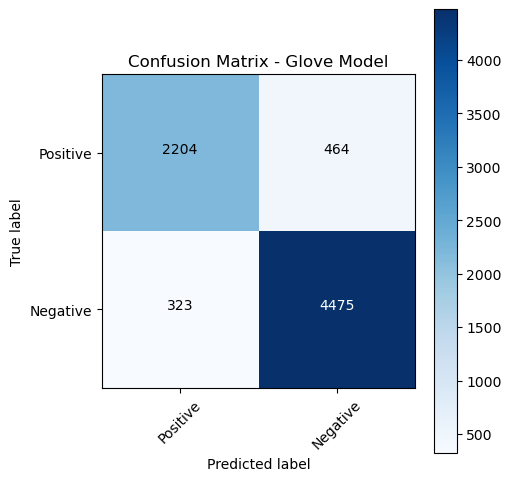

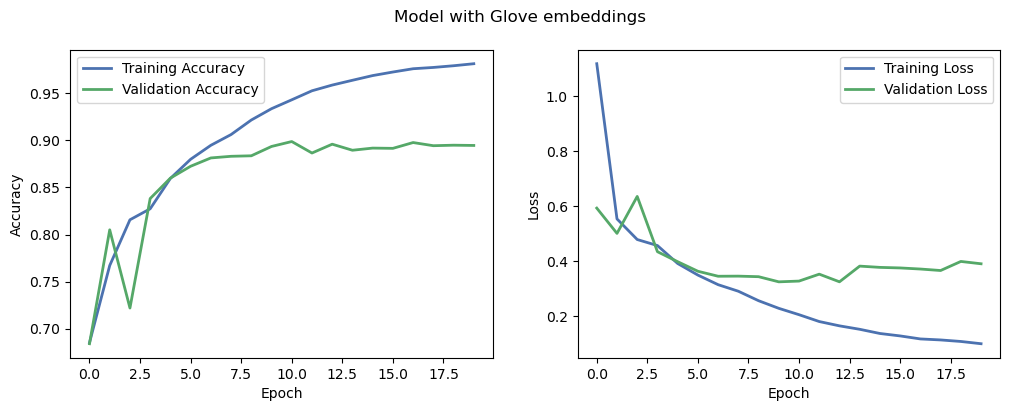

In [42]:
X_test = test_df['tweets']
y_test = test_df['labels']

# Get predictions on test data
y_pred = model.predict(test_df['tweets'])

# Convert probabilities to binary predictions
y_pred_binary = (y_pred > 0.5).astype(int)

# Calculate confusion matrix
cm1 = confusion_matrix(y_test, y_pred_binary)

# Plot confusion matrix for Glove model
plot_confusion_matrix(cm1, classes, title='Confusion Matrix - Glove Model')

# Plot the training and validation accuracy and loss
plot_history(history1, title='Model with Glove embeddings')

In [43]:
print(classification_report(test_df['labels'], y_pred_binary, target_names=['Positive', 'Negative']))

              precision    recall  f1-score   support

    Positive       0.87      0.83      0.85      2668
    Negative       0.91      0.93      0.92      4798

    accuracy                           0.89      7466
   macro avg       0.89      0.88      0.88      7466
weighted avg       0.89      0.89      0.89      7466



In [44]:
# Train and evaluate the ConceptNet model
model2 = model_with_numberbatch_embeddings()
history2, model2 = train_and_evaluate_model(model2, train_df=train_df, test_df=test_df, epochs=epochs)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_3            │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_9 (Embedding)         │ (None, 100, 300)       │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 128)       │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,227,969 (23.76 MB)

 Trainable params: 227,969 (890.50 KB)

 Non-trainable params: 6,000,000 (22.89 MB)

Epoch 1/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 64s 67ms/step - accuracy: 0.6545 - loss: 2.2700 - val_accuracy: 0.6426 - val_loss: 0.6764
Epoch 2/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.6421 - loss: 0.6656 - val_accuracy: 0.6426 - val_loss: 0.6661
Epoch 3/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.6472 - loss: 0.6397 - val_accuracy: 0.6538 - val_loss: 0.6565
Epoch 4/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 62s 67ms/step - accuracy: 0.7045 - loss: 0.6056 - val_accuracy: 0.7574 - val_loss: 0.5461
Epoch 5/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.7646 - loss: 0.5325 - val_accuracy: 0.7932 - val_loss: 0.5018
Epoch 6/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.8097 - loss: 0.4725 - val_accuracy: 0.8204 - val_loss: 0.4509
Epoch 7/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.8272 - loss: 0.4477 - val_accuracy: 0.8371 - val_loss: 0.4245
Epoch 8/20
934/934 ━━━━━━━━━━━━━━━━━━━━ 62s 67ms/step - accuracy: 0.8526 - loss: 0.4022 - 

234/234 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step


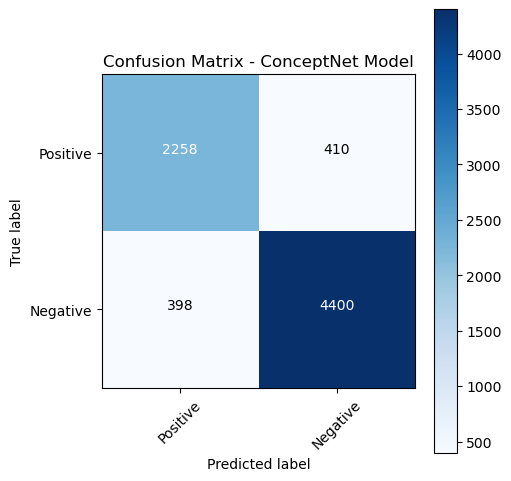

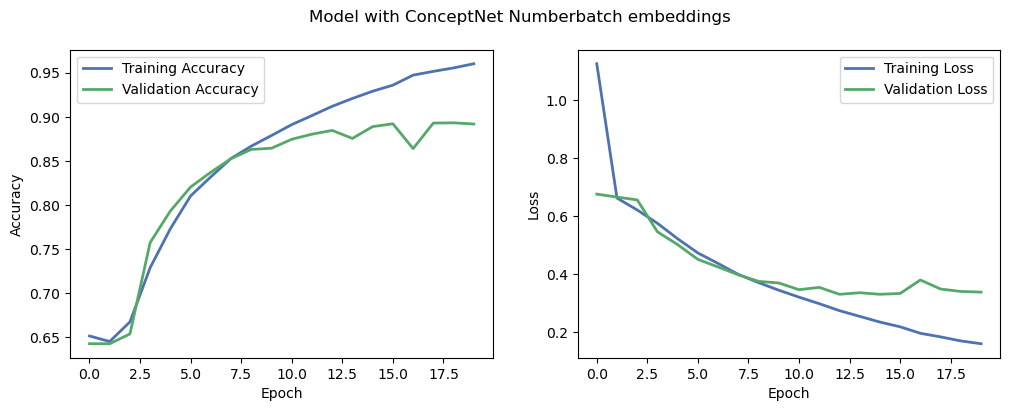

In [46]:
# Get predictions on test data
y_pred = model2.predict(test_df['tweets'])

# Convert probabilities to binary predictions
y_pred_binary = (y_pred > 0.5).astype(int)

# Calculate confusion matrix
cm2 = confusion_matrix(y_test, y_pred_binary)

# Plot confusion matrix for ConceptNet model
plot_confusion_matrix(cm2, classes, title='Confusion Matrix - ConceptNet Model')

# Plot the training and validation accuracy and loss
plot_history(history2, title='Model with ConceptNet Numberbatch embeddings')

In [47]:
print(classification_report(test_df['labels'], y_pred_binary, target_names=['Positive', 'Negative']))

              precision    recall  f1-score   support

    Positive       0.85      0.85      0.85      2668
    Negative       0.91      0.92      0.92      4798

    accuracy                           0.89      7466
   macro avg       0.88      0.88      0.88      7466
weighted avg       0.89      0.89      0.89      7466

